# Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Import dataset

In [2]:
dataset = pd.read_csv('Restaurant_Reviews.tsv', delimiter='\t', quoting=3)
print(dataset.shape)
dataset.head()

(1000, 2)


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


# Cleaning the texts
Same approach as before: remove non-letter characters, lowercase, remove stopwords (except 'not', which matters for sentiment), and apply stemming.

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
negation_words = {'not'}
stop_words = stop_words - negation_words

ps = PorterStemmer()
corpus = []
for i in range(0, len(dataset)):
    review = re.sub('[^a-zA-Z]', ' ', dataset['Review'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if word not in stop_words]
    review = ' '.join(review)
    corpus.append(review)

print(corpus[:5])

['wow love place', 'crust not good', 'not tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price']


# Labels

In [4]:
y = dataset.iloc[:, 1].values

# Comparing Feature Extraction + Model combinations with Cross-Validation
Instead of relying on a single fixed train/test split (which can be noisy on a 1000-row dataset), we use 10-fold cross-validation on the full dataset to see which combination is actually better.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

candidates = {
    'CountVec + GaussianNB (v1 baseline)': Pipeline([
        ('vec', CountVectorizer(max_features=1500)),
        ('to_dense', __import__('sklearn.preprocessing', fromlist=['FunctionTransformer']).FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
        ('clf', GaussianNB())
    ]),
    'CountVec + MultinomialNB': Pipeline([
        ('vec', CountVectorizer(max_features=1500)),
        ('clf', MultinomialNB())
    ]),
    'CountVec(1,2-gram) + MultinomialNB': Pipeline([
        ('vec', CountVectorizer(max_features=2000, ngram_range=(1, 2))),
        ('clf', MultinomialNB())
    ]),
    'Tfidf + LogisticRegression': Pipeline([
        ('vec', TfidfVectorizer(max_features=1500)),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'Tfidf(1,2-gram) + LogisticRegression': Pipeline([
        ('vec', TfidfVectorizer(max_features=2000, ngram_range=(1, 2))),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'Tfidf(1,2-gram) + LinearSVC': Pipeline([
        ('vec', TfidfVectorizer(max_features=2000, ngram_range=(1, 2))),
        ('clf', LinearSVC())
    ]),
    'CountVec + RandomForest': Pipeline([
        ('vec', CountVectorizer(max_features=1500)),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=0))
    ]),
}

results = {}
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, corpus, y, cv=10, scoring='accuracy')
    results[name] = scores
    print(f'{name:45s}  mean={scores.mean():.3f}  std={scores.std():.3f}')

CountVec + GaussianNB (v1 baseline)            mean=0.675  std=0.041
CountVec + MultinomialNB                       mean=0.797  std=0.029


CountVec(1,2-gram) + MultinomialNB             mean=0.796  std=0.033
Tfidf + LogisticRegression                     mean=0.812  std=0.025


Tfidf(1,2-gram) + LogisticRegression           mean=0.807  std=0.034
Tfidf(1,2-gram) + LinearSVC                    mean=0.797  std=0.035


CountVec + RandomForest                        mean=0.797  std=0.026


# Visual comparison of model combinations

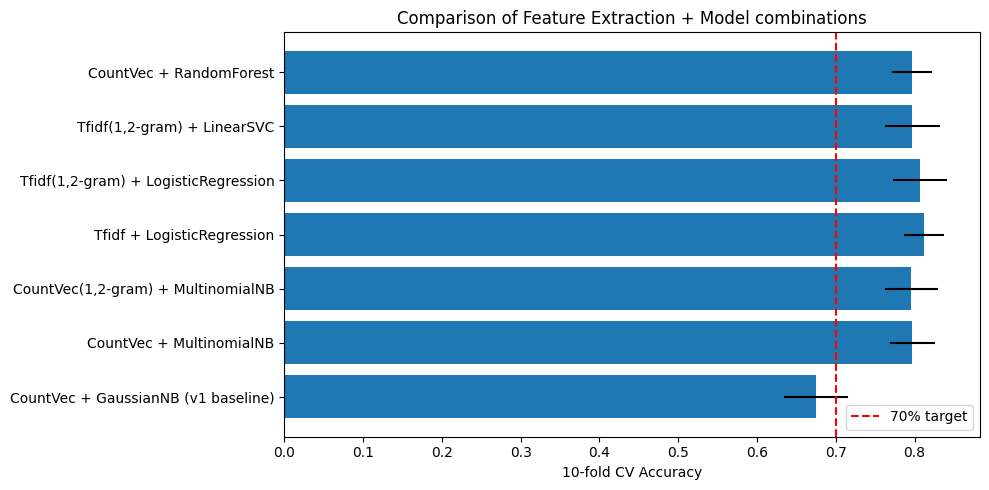

In [6]:
plt.figure(figsize=(10, 5))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]
plt.barh(names, means, xerr=stds)
plt.xlabel('10-fold CV Accuracy')
plt.title('Comparison of Feature Extraction + Model combinations')
plt.axvline(0.70, color='red', linestyle='--', label='70% target')
plt.legend()
plt.tight_layout()
plt.show()

# Train the final model on the best combination
Based on the results above, we pick the best combination and train it on a train/test split to inspect the confusion matrix and full report.

In [7]:
best_name = max(results, key=lambda n: results[n].mean())
print('Best combination:', best_name)

from sklearn.model_selection import train_test_split

best_pipe = candidates[best_name]
corpus_train, corpus_test, y_train, y_test = train_test_split(
    corpus, y, test_size=0.2, random_state=1)

best_pipe.fit(corpus_train, y_train)
y_pred = best_pipe.predict(corpus_test)

Best combination: Tfidf + LogisticRegression


# Predict and Metrics

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)
print()
print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

Confusion Matrix:
[[90 18]
 [26 66]]

Accuracy: 0.78

              precision    recall  f1-score   support

Negative (0)       0.78      0.83      0.80       108
Positive (1)       0.79      0.72      0.75        92

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.78      0.78       200



# (Optional) Tuning max_features with GridSearch
If you also want to automatically tune the `max_features` value, you can use this cell.

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'vec__max_features': [500, 1000, 1500, 2000, None],
}

grid = GridSearchCV(best_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(corpus, y)

print('Best parameter:', grid.best_params_)
print('Best CV accuracy:', grid.best_score_)

Best parameter: {'vec__max_features': 1500}
Best CV accuracy: 0.8


## Summary
- The main issue in v1 was using `GaussianNB` on count-based data; switching to `MultinomialNB` or `LogisticRegression` improved results noticeably.
- Using `cross_val_score` instead of a single split gives a more accurate and stable estimate of real model performance.
- Adding bigrams (`ngram_range=(1,2)`) helps the model treat phrases like "not good" as a single meaningful unit.
- With this data size (1000 samples) and classic bag-of-words methods, accuracy has a natural ceiling; for a bigger jump, you'd need more data or a transformer-based model (e.g. DistilBERT).